In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np

import networkx as nx

from pathlib import Path
import os

from enum import Enum

from fame import *

import plotly.express as px
from matplotlib.pyplot import cm

import random


In [2]:
R_earth_km = 6371


In [3]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
# tle_file_name_txt = "all_tles_20260130.txt"


In [6]:
# planet_satellites = []
# 14-19 decayed

instrument_types = ["RGB", "Hyperspectral", "SAR"]

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=["Hyperspectral"], has_continuous_isl_to_ground=True),
]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True)]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True)]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=["RGB"], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [7]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [8]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {"RGB": _fov}

In [9]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [10]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

### Communication opportunities

In [11]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [12]:
min_time=dt.datetime.now(dt.timezone.utc)
max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

## Dispatching the workflow

We now have a graph with one .observation_opportunity per ConstrainedObservationRequest. When do we actually dispatch it?

Idea: when the parent constraint are satisfied (per the dispatch policy). 
We will also have to separately handle "what if we dispatch before a constraint is resolved, and it gets resolved in a way we did not expect".

So:
- Go over the list of tasks
- If a task is not Dispatched
- Check their constraints according to the mask in .dispatch_policy
- If it is dispatchable
- Dispatch it

In [13]:
min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

In [14]:
phenomenon_update_frequency = dt.timedelta(seconds=1800)

avg_speed_kph = 37 # 20 kts
start_speed_kph = avg_speed_kph
start_heading_deg = 0
heading_variance = .075
speed_variance = 0.5

phenomena = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=min_time+phenomenon_update_frequency,
        name = Rotterdam.name,
        heading_deg=start_heading_deg,
        speed_kph=start_speed_kph
    ),
]


max_iters_per_point = 5000


start_speed_kph = avg_speed_kph
start_heading_deg = 0

new_heading_rad = start_heading_deg*np.pi/180.

random.seed(4)

while phenomena[-1].end_time<max_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena[-1].end_time
    

    phenomena.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena_with_stationary_toi = [p for p in phenomena]

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=max_time,
        name = Rotterdam.name+ " stationary"
    ),
)

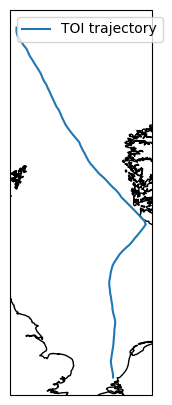

In [15]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in phenomena],[pos.lat_deg for pos in phenomena],transform=ccrs.Geodetic(), label="TOI trajectory")


axglobal.legend()


In [16]:
# phenomena = []

world_with_brokers = World(satellites = all_satellites, phenomena=phenomena_with_stationary_toi)

scheduler_planet = ConstellationGroundScheduler(satellites=skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")

world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)

world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers)

world_with_brokers.add_broker(broker)
world_with_brokers.time = min_time

A few items to fix.
- If a task is not scheduled, how should constraints that depend on this task be resolved? Do we ignore the constraints (which is what we do now, kind of)? Or do we invalidate all follow-ups?
  - For geometry constraints, we can only invalidate.
  - For temporal constraints, we could go either way.
  - Do we need a more complex syntax for tasks? Like an EITHER/OR thing.
  

In [17]:


obs_request_initial_msa = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument="RGB"
    )

obs_request_followup_no_msa = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument="RGB"
    )

obs_request_followup_yes_msa = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up SAR request in Rotterdam",
    min_elevation_deg=45,
    instrument="SAR"
    )

In [18]:


dt_h = 3

ship_location_timeline_msa = Timeline(name="[MSA] Do we know where the ship is?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)



constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial_msa,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

workflow_msa_reqs = [constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,24,dt_h)):

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    if len(workflow_msa_reqs)>1:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up observation {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    obs_srch_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    if len(workflow_msa_reqs)>1:
        obs_srch_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        )

    # If the prior fails, do a search
    constrained_followup_search_later = ConstrainedObservationRequest(
        name="Follow-up search {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_no_msa,
        task_constraints = obs_srch_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    workflow_msa_reqs.append(constrained_followup_search_later)
    workflow_msa_reqs.append(constrained_followup_observation_later)

def timeline_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800), verbose=True):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines

workflow_msa = Workflow(
    constrained_observation_requests=workflow_msa_reqs,
    timelines = [ship_location_timeline_msa,],
    timeline_updater=timeline_updater_msa
)

In [19]:
broker.add_workflow(workflow_msa)

   [Scheduler] WG: MultiDiGraph with 15 nodes and 54 edges
    [Scheduler] Solved to optimality; objective value = 92.08823182281384
    [Scheduler]  Initial observation with 0 task constraints_Ubotica CogniSat-6 HAMMER_Pass start: 2026-04-21 02:40:31.877868, highest: 2026-04-21 02:40:45.847337, fall: 2026-04-21 02:40:59.816806  =  1.0
    [Scheduler]  Follow-up search 1 with 3 task constraints_SKYSAT-C3_Pass start: 2026-04-21 08:06:04.300986, highest: 2026-04-21 08:06:55.232703, fall: 2026-04-21 08:07:46.164420  =  1.0
    [Scheduler]  Follow-up search 2 with 4 task constraints_SKYSAT-A_Pass start: 2026-04-21 09:30:05.305160, highest: 2026-04-21 09:30:59.483759, fall: 2026-04-21 09:31:53.662356  =  1.0
    [Scheduler]  Follow-up search 3 with 4 task constraints_SKYSAT-C6_Pass start: 2026-04-21 14:38:20.418296, highest: 2026-04-21 14:38:56.141076, fall: 2026-04-21 14:39:31.863855  =  1.0
    [Scheduler]  Follow-up search 4 with 4 task constraints_Ubotica CogniSat-6 HAMMER_Pass start: 2

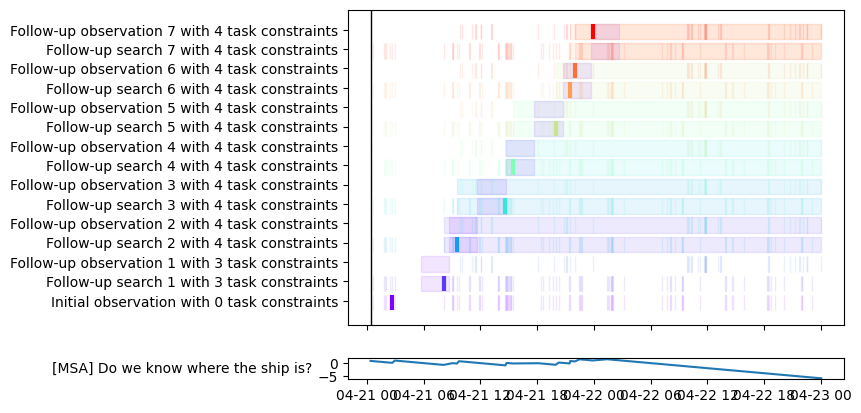

In [20]:
broker.schedule_workflow(current_time=world_with_brokers.time, use_ilp=True, plot_schedule=True, update_timelines=False)

Executing Event Obs, sat Ubotica CogniSat-6 HAMMER at 2026-04-21 02:40:45.847337
Executing Event ISL Downlink from sat Ubotica CogniSat-6 HAMMER at 2026-04-21 02:40:45.847337
Spacecraft Ubotica CogniSat-6 HAMMER has 1 data products to download
  Downlinked Observation  at 2026-04-21 02:40:45.847337 with RGB. Look angle 259.95662893046955 | 46.053826286687645 az/dec deg, zenith angle 105.65236744063081 deg, range 577.6142481563162 km, duration 0:01:00
 [Broker: ] data ready for request Request Initial RGB request in Rotterdam, pass Pass start: 2026-04-21 02:40:31.877868, highest: 2026-04-21 02:40:45.847337, fall: 2026-04-21 02:40:59.816806, from UBOTICA
    [Dispatcher] Resetting timeline Timeline [MSA] Do we know where the ship is? with 2 impacts to 1 (est rate -9.259259259259259e-05) at time 2026-04-21 02:40:45.847337
   [Scheduler] WG: MultiDiGraph with 15 nodes and 54 edges
   [Scheduler] Request Initial observation with 0 task constraints is already dispatched or completed, skippin

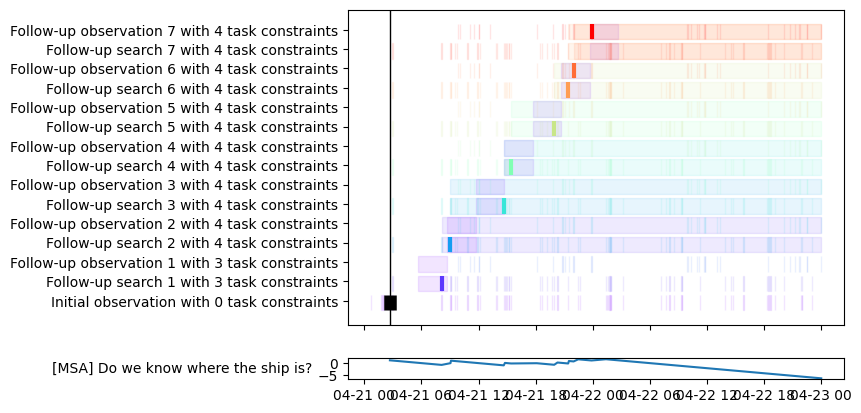

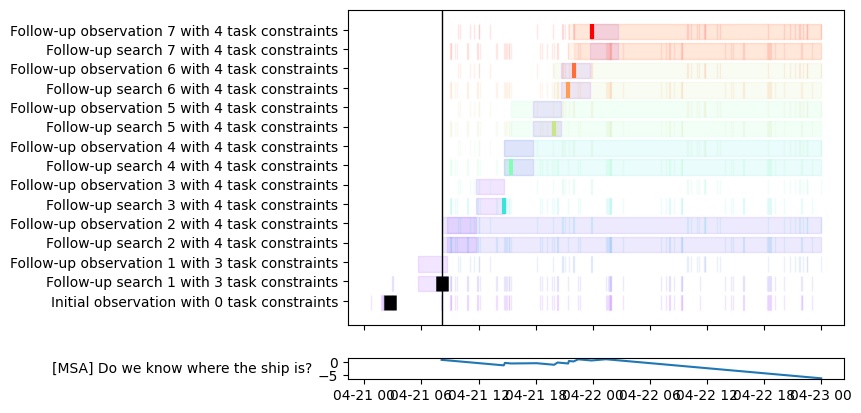

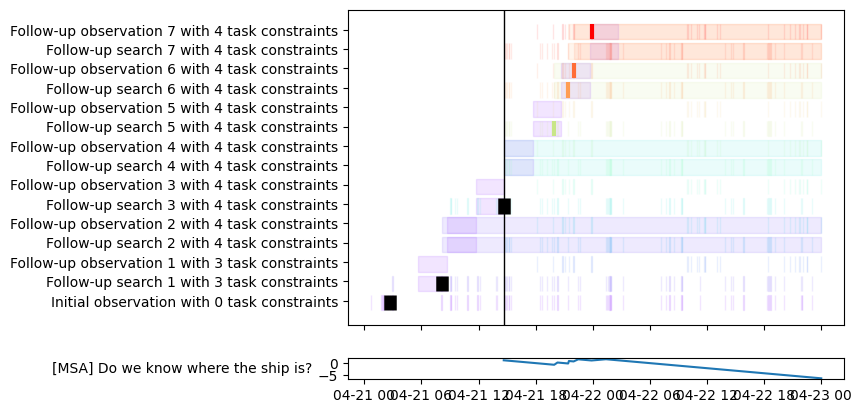

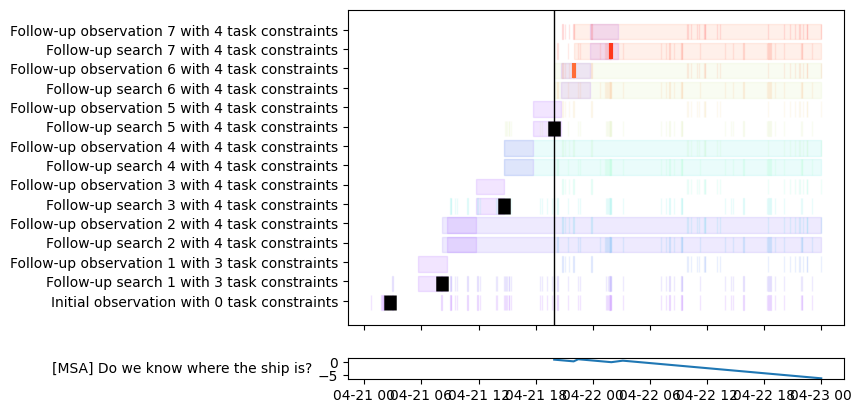

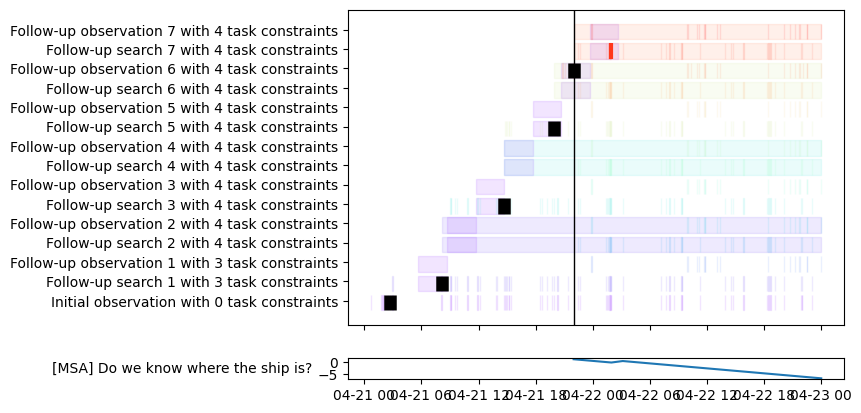

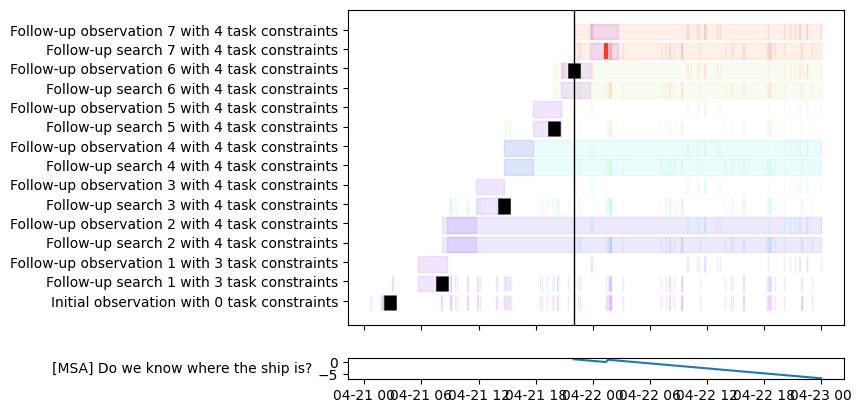

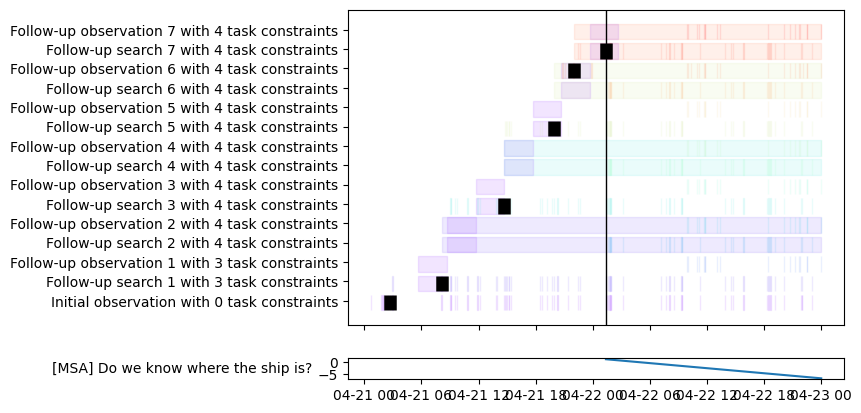

In [21]:
retcode = 1
while (retcode !=0):
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

In [22]:
broker._requests.columns

Index(['request', 'requested_pass', 'requested_constellation',
       'requested_satellite', 'constellation', 'satellite', 'assigned_pass',
       'assigned_downlink', 'status', 'data_product', 'scheduled_callback',
       'unscheduled_callback', 'ready_callback'],
      dtype='object')

In [23]:
retell_history(world_with_brokers)

Time: 2026-04-21 02:40:45.847337. Event: Event Obs, sat Ubotica CogniSat-6 HAMMER at 2026-04-21 02:40:45.847337
Observation: sat Ubotica CogniSat-6 HAMMER and opportunity Observation  at 2026-04-21 02:40:45.847337 with RGB. Look angle 259.95662893046955 | 46.053826286687645 az/dec deg, zenith angle 105.65236744063081 deg, range 577.6142481563162 km, duration 0:01:00
Time: 2026-04-21 02:40:45.847337. Event: Event ISL Downlink from sat Ubotica CogniSat-6 HAMMER at 2026-04-21 02:40:45.847337
Communication: station ISL to sat Ubotica CogniSat-6 HAMMER during pass ISL
Time: 2026-04-21 02:41:45.847337. Event: Event Unlock satellite after obs, sat Ubotica CogniSat-6 HAMMER at 2026-04-21 02:41:45.847337
Time: 2026-04-21 08:06:55.232703. Event: Event Obs, sat SKYSAT-C3 at 2026-04-21 08:06:55.232703
Observation: sat SKYSAT-C3 and opportunity Observation  at 2026-04-21 08:06:55.232703 with RGB. Look angle 285.05815922596355 | 74.5141658083799 az/dec deg, zenith angle 58.98214307928144 deg, range 

In [24]:
request_statistics(broker._requests)

6/7 (85.71428571428571%) of requests are in status ObservationStatus.DATA_RECEIVED
1/7 (14.285714285714285%) of requests are in status ObservationStatus.NO_OBSERVATION_OPPORTUNITIES
 3/3 (100.0%) unique requests have at least one successful observation
3/3 (100.0%) of all successful unique requests have a phenomenon detection


In [25]:
# broker._requests.loc[broker._requests['assigned_pass']!=None]
broker._requests.loc[broker._requests['status']==ObservationStatus.DATA_RECEIVED]

,request,requested_pass,requested_constellation,requested_satellite,constellation,satellite,assigned_pass,assigned_downlink,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,Request Initial RGB request in Rotterdam,"Pass start: 2026-04-21 02:40:31.877868, highes...",Constellation scheduler UBOTICA with 1 satellites,Ubotica CogniSat-6 HAMMER,Constellation scheduler UBOTICA with 1 satellites,Ubotica CogniSat-6 HAMMER,Observation at 2026-04-21 02:40:45.847337 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...
1,Request Follow-up search request in Rotterdam,"Pass start: 2026-04-21 08:06:04.300986, highes...",Constellation scheduler Planet with 22 satellites,SKYSAT-C3,Constellation scheduler Planet with 22 satellites,SKYSAT-C3,Observation at 2026-04-21 08:06:55.232703 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...
2,Request Follow-up search request in Rotterdam,"Pass start: 2026-04-21 14:38:20.418296, highes...",Constellation scheduler Planet with 22 satellites,SKYSAT-C6,Constellation scheduler Planet with 22 satellites,SKYSAT-C6,Observation at 2026-04-21 14:38:56.141076 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...
3,Request Follow-up search request in Rotterdam,"Pass start: 2026-04-21 19:56:36.656327, highes...",Constellation scheduler Planet with 22 satellites,SKYSAT-C13,Constellation scheduler Planet with 22 satellites,SKYSAT-C13,Observation at 2026-04-21 19:57:12.073623 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...
4,Request Follow-up SAR request in Rotterdam,"Pass start: 2026-04-21 21:58:53.658174, highes...",Constellation scheduler Capella with 6 satellites,CAPELLA-16 (ACADIA-6),Constellation scheduler Capella with 6 satellites,CAPELLA-16 (ACADIA-6),Observation at 2026-04-21 21:59:42.630592 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...
6,Request Follow-up search request in Rotterdam,"Pass start: 2026-04-22 01:22:57.493696, highes...",Constellation scheduler Planet with 22 satellites,SKYSAT-C7,Constellation scheduler Planet with 22 satellites,SKYSAT-C7,Observation at 2026-04-22 01:23:37.796396 wit...,None,ObservationStatus.DATA_RECEIVED,"[Rotterdam-ish stationary: Lon 3.8°, lat 52°, ...",<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...,<function Broker.schedule_workflow.<locals>.ca...


In [26]:
[broker._workflow_graph.nodes[n] for n in broker._workflow_graph.nodes]

[{'observation_request': Request Initial RGB request in Rotterdam,
  'task_constraints': [],
  'timeline_constraints': [],
  'timeline_impacts': [<fame_workflow.TaskTimelineImpact at 0x136eca7b0>],
  'is_mandatory': True,
  'schedule_policy': {<ConstraintClass.TEMPORAL: 0>: True,
   <ConstraintClass.SUCCESS: 1>: True,
   <ConstraintClass.GEOMETRY: 2>: True},
  'dispatch_policy': {<ConstraintClass.TEMPORAL: 0>: False,
   <ConstraintClass.SUCCESS: 1>: False,
   <ConstraintClass.GEOMETRY: 2>: False},
  'success_declarer': <function __main__.<lambda>(data_product)>,
  'follow_up_action_failure': <function fame_workflow.ConstrainedObservationRequest.<lambda>(reason)>,
  'follow_up_action_success': <function fame_workflow.ConstrainedObservationRequest.<lambda>(data_product)>,
  'observation_opportunity': None,
  'observation_opportunity_pass': None,
  'observation_opportunity_satellite': None,
  'observation_opportunities': {},
  'scheduled': False,
  'feasible': True,
  'dispatched': False,